# Тема 7. Обучение без учителя: PCA и кластеризация

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Три темы:

1. k-Means не всегда справляется — иерархическая кластеризация на «лунах»
2. Как оценивать кластеризацию, когда правильный ответ всё-таки известен
3. Кластеризация текстов: жёсткая проверка на данных из темы 6

(В оригинальном курсе mlcourse.ai здесь ещё разбирается кластеризация лиц (LFW) — мы не включаем: датасет ~200 МБ, скачивается из интернета при первом запуске, не подходит для оффлайн-занятия. Идея та же, что ниже с текстами — просто вместо слов признаки-пиксели.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.feature_extraction.text import TfidfVectorizer

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Когда k-Means не справляется

k-Means по устройству алгоритма (расстояние до центра) хорошо находит **выпуклые, примерно круглые** кластеры. На данных другой формы он ошибается систематически — не из-за неудачной инициализации, а потому что сама идея «раздели по расстоянию до центра» здесь не подходит.

**Агломеративная (иерархическая) кластеризация** — другой принцип: начинаем с того, что каждая точка — свой кластер, и на каждом шаге объединяем два ближайших кластера, пока не останется нужное число. Не привязана к форме «круглых облаков».

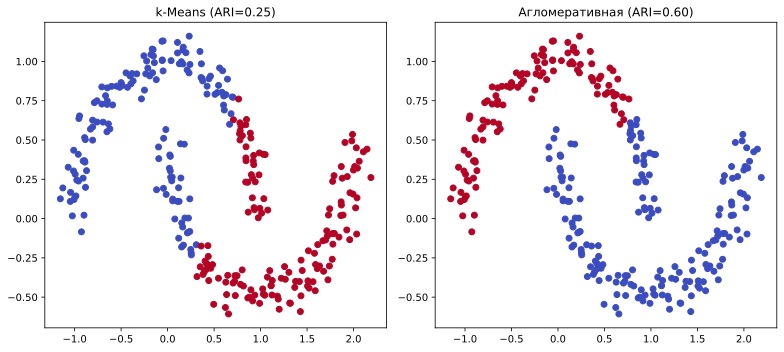

In [2]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=RANDOM_STATE)

km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_moons)
agg = AgglomerativeClustering(n_clusters=2).fit(X_moons)

_, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=km.labels_, cmap="coolwarm")
axes[0].set_title(f"k-Means (ARI={adjusted_rand_score(y_moons, km.labels_):.2f})")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=agg.labels_, cmap="coolwarm")
axes[1].set_title(f"Агломеративная (ARI={adjusted_rand_score(y_moons, agg.labels_):.2f})")
plt.tight_layout();

k-Means режет пространство пополам прямой линией (ему больше нечем) и разваливает каждую «луну» примерно на середине. Агломеративная кластеризация, объединяя ближайших соседей шаг за шагом, куда честнее следует форме данных.

---
## 2. Оценка кластеризации, когда ответ известен

На занятии мы использовали силуэт — он не требует знать «правильные» метки (у нас их и не было, в этом смысл кластеризации). Но иногда правильная разбивка всё же известна заранее (как здесь, с `make_moons`, или как в теме 7 практики, где мы сверяли кластеры с `Survived`) — тогда можно использовать **Adjusted Rand Index (ARI)**: сравнивает, насколько два разбиения (найденное и истинное) совпадают, с поправкой на случайное совпадение. `1` — совпадение полное, `0` — не лучше случайного разбиения, ARI посчитан для примера выше.

**Важно не путать два сценария:** силуэт годится всегда (истинные метки не нужны), ARI/подобные метрики — только если у вас **есть** с чем сравнивать (для отладки на синтетике или пост-фактум проверки, как в практике этого занятия).

---
## 3. Кластеризация текстов: честная проверка

В теме 6 мы обучали TF-IDF + логрегрессию на SMS-сообщениях (spam/ham) — с учителем, зная метки. Проверим: если забыть про метки и просто кластеризовать тексты по словам — найдётся ли разбиение на spam/ham само?

In [3]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "text"]

tfidf = TfidfVectorizer(max_features=1000, stop_words="english", min_df=5)
X_text = tfidf.fit_transform(df["text"])

km_text = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = km_text.fit_predict(X_text)

pd.crosstab(df["cluster"], df["label"])

label,ham,spam
cluster,,
0,4594,747
1,231,0


Разбиение **не** совпало с `spam`/`ham` чисто — один кластер почти целиком «ham» (не спам), но маленький, а основная масса перемешана в другом. Причина: TF-IDF-расстояние между текстами реагирует на **любую** тематическую разницу (спам про выигрыши vs. спам про подписки — тоже «разные» тексты), а не только на признак «это спам или нет». k-Means нашёл какую-то реальную структуру в данных — просто не ту, которую мы надеялись увидеть.

**Урок применим шире, чем к тексту:** кластеризация находит структуру, которая реально доминирует в данных по выбранной метрике расстояния, а не ту, что важна лично вам. Если конкретная разметка важна — это задача для обучения **с учителем** (темы 3-6), а не для кластеризации.

---
## Итог

Дальше в программе курса — `lesson08_gradient_boosting_theory.ipynb`.